# Clustering Satellite Climatologies in the Gulf Stream

Using monthly avg chl, ADT (and temp) to get spatial clusters of the region. Monthly avgs calculated in `gulf_stream_satellite_clim.ipynb`.

LJK

Date created: 05/30/25

Last edited: 05/30/25

In [47]:
import random
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [48]:
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

Open climatological datasets

In [49]:
chl_ds = xr.open_dataset('data/monthly_chl_avg_2000_to_2020_OCCCI-4km_GEO_PML_OCx-201612-fv6.0_Gulf_Stream_crop.nc')
chl_ds

<xarray.Dataset> Size: 308kB
Dimensions:    (month: 12, latitude: 40, longitude: 80)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float32 160B 32.12 32.38 32.62 ... 41.38 41.62 41.88
  * longitude  (longitude) float32 320B 280.1 280.4 280.6 ... 299.4 299.6 299.9
Data variables:
    chl        (month, latitude, longitude) float64 307kB ...

In [50]:
ADT_ds = xr.open_dataset('data/monthly_ADT_avg_2000_to_2020_CMEMS_dt_global_allsat_Gulf_Stream_crop.nc')
ADT_ds

<xarray.Dataset> Size: 308kB
Dimensions:    (month: 12, latitude: 40, longitude: 80)
Coordinates:
  * latitude   (latitude) float32 160B 32.12 32.38 32.62 ... 41.38 41.62 41.88
  * longitude  (longitude) float32 320B 280.1 280.4 280.6 ... 299.4 299.6 299.9
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    ADT        (month, latitude, longitude) float64 307kB ...

## K-means Clustering
Clustering inspo from PACE Hackweek 2024 K-means group: https://github.com/khyde/kae_means/blob/main/kaemeans_workflow.ipynb

In [51]:
def cluster_clim_data(cluster_num):
    """
    cluster_num: number of clusters to compute

    returns a cluster climatology
    """
    
    cluster_clim = []
    for m in np.arange(0,12): # iterate through the months
        X = pd.DataFrame({'CHL': chl_ds.chl[m].values.flatten(),
                          'ADT': ADT_ds.ADT[m].values.flatten(),})
    
        # Remove NaN's
        good_inds = np.where(X.isna().sum(axis = 1)==0)[0]
        X = X.iloc[good_inds, :] # only contains non-NaN data now
        
        # Standardize input feautres
        scaler = StandardScaler().fit(X)
        X_scaled = scaler.transform(X)

        # K-means clustering
        kmeans_fit = KMeans(n_clusters=cluster_num).fit(X_scaled)
        cluster_labels = kmeans_fit.predict(X_scaled) # integers associated w/ the cluster

        # Reshape back to the original grid
        cluster_grid = np.full(chl_ds.chl[0].shape, np.nan) # intialize with nan's'
        cluster_grid[np.unravel_index(good_inds, cluster_grid.shape)]=cluster_labels
        cluster_clim.append(cluster_grid)
        
    return cluster_clim

In [52]:
def plot_clusters(cluster_clim):
    fig,ax = plt.subplots(4,3,figsize=(25,15))
    plt.subplots_adjust(wspace=0.05, hspace=0.1) # make plots closer together
    
    month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
    months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
    
    def plot_row_by_season(row_ind,array_of_months):
        i = 0
        for m in array_of_months:
            plot = ax[row_ind,i].pcolormesh(chl_ds.longitude,chl_ds.latitude,cluster_clim[3*row_ind+i],shading='nearest')
            ax[row_ind,i].text(281,40,months[month_list.index(m)],color='k',fontweight='bold')
            i += 1
        return plot
    
    plot = plot_row_by_season(0,['12','01','02']) # Winter
    plot = plot_row_by_season(1,['03','04','05']) # Spring
    plot = plot_row_by_season(2,['06','07','08']) # Summer
    plot = plot_row_by_season(3,['09','10','11']) # Fall
    
    # Colorbar
    #fig.subplots_adjust(right=0.8)
    #cbar_ax = fig.add_axes([0.81, 0.15, 0.01, 0.7]) #[left, bottom, width, height]
    #fig.colorbar(plot, cax=cbar_ax)
    #cbar_ax.set_ylabel('Clusters', rotation=270)
    #cbar_ax.get_yaxis().labelpad = 30
    
    ax[3,0].set_xlabel('Longitude')
    ax[3,0].set_ylabel('Latitude')
    
    for row in range(4):
        for col in range(3):
            if row != 3:
                ax[row,col].set_xticklabels([])
            if col != 0:
                ax[row,col].set_yticklabels([])
    
    plt.show()

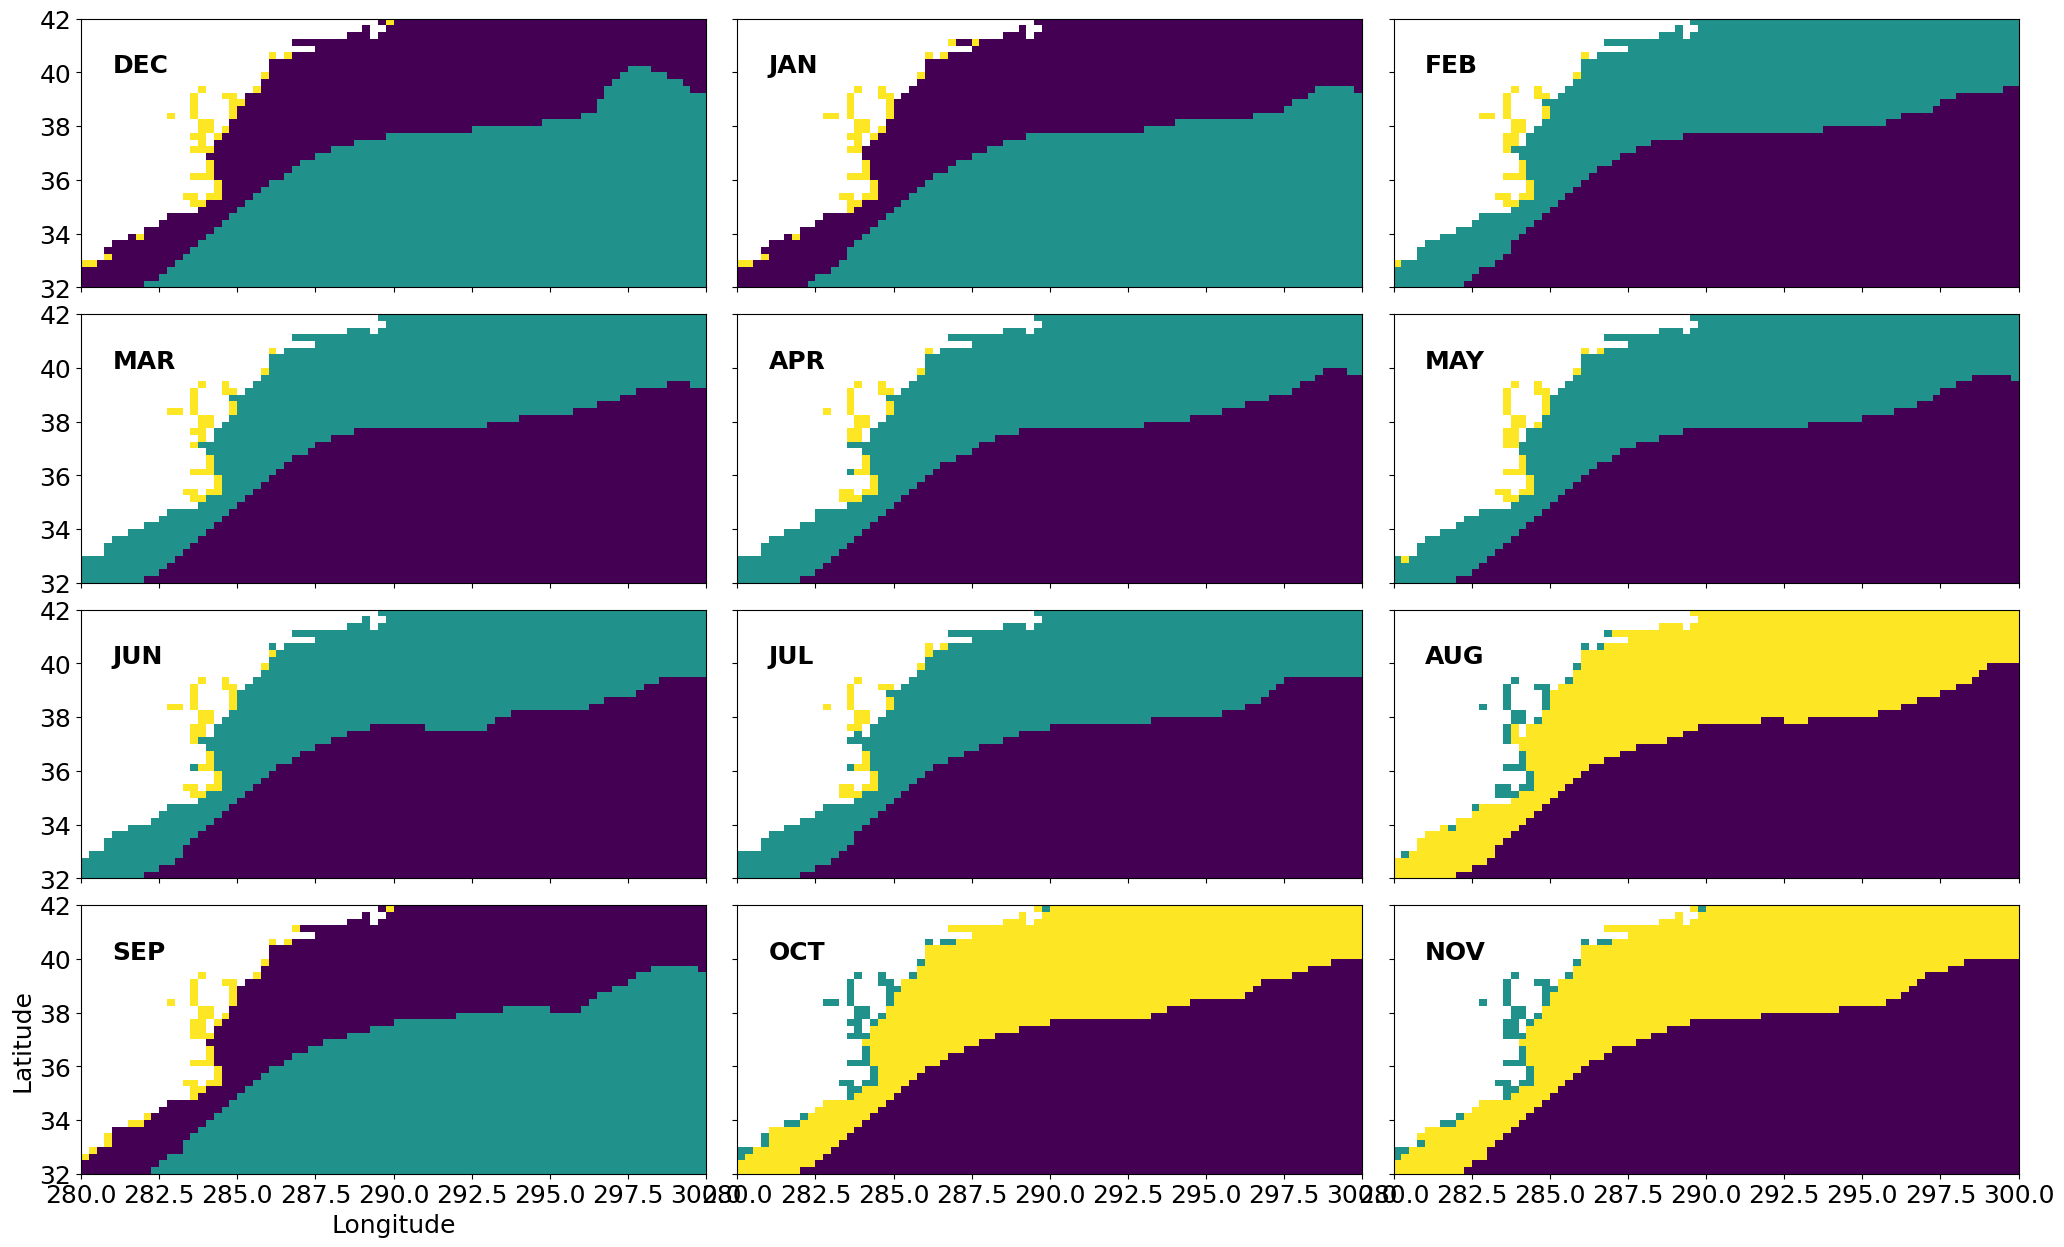

In [53]:
plot_clusters(cluster_clim_data(3)) #correct

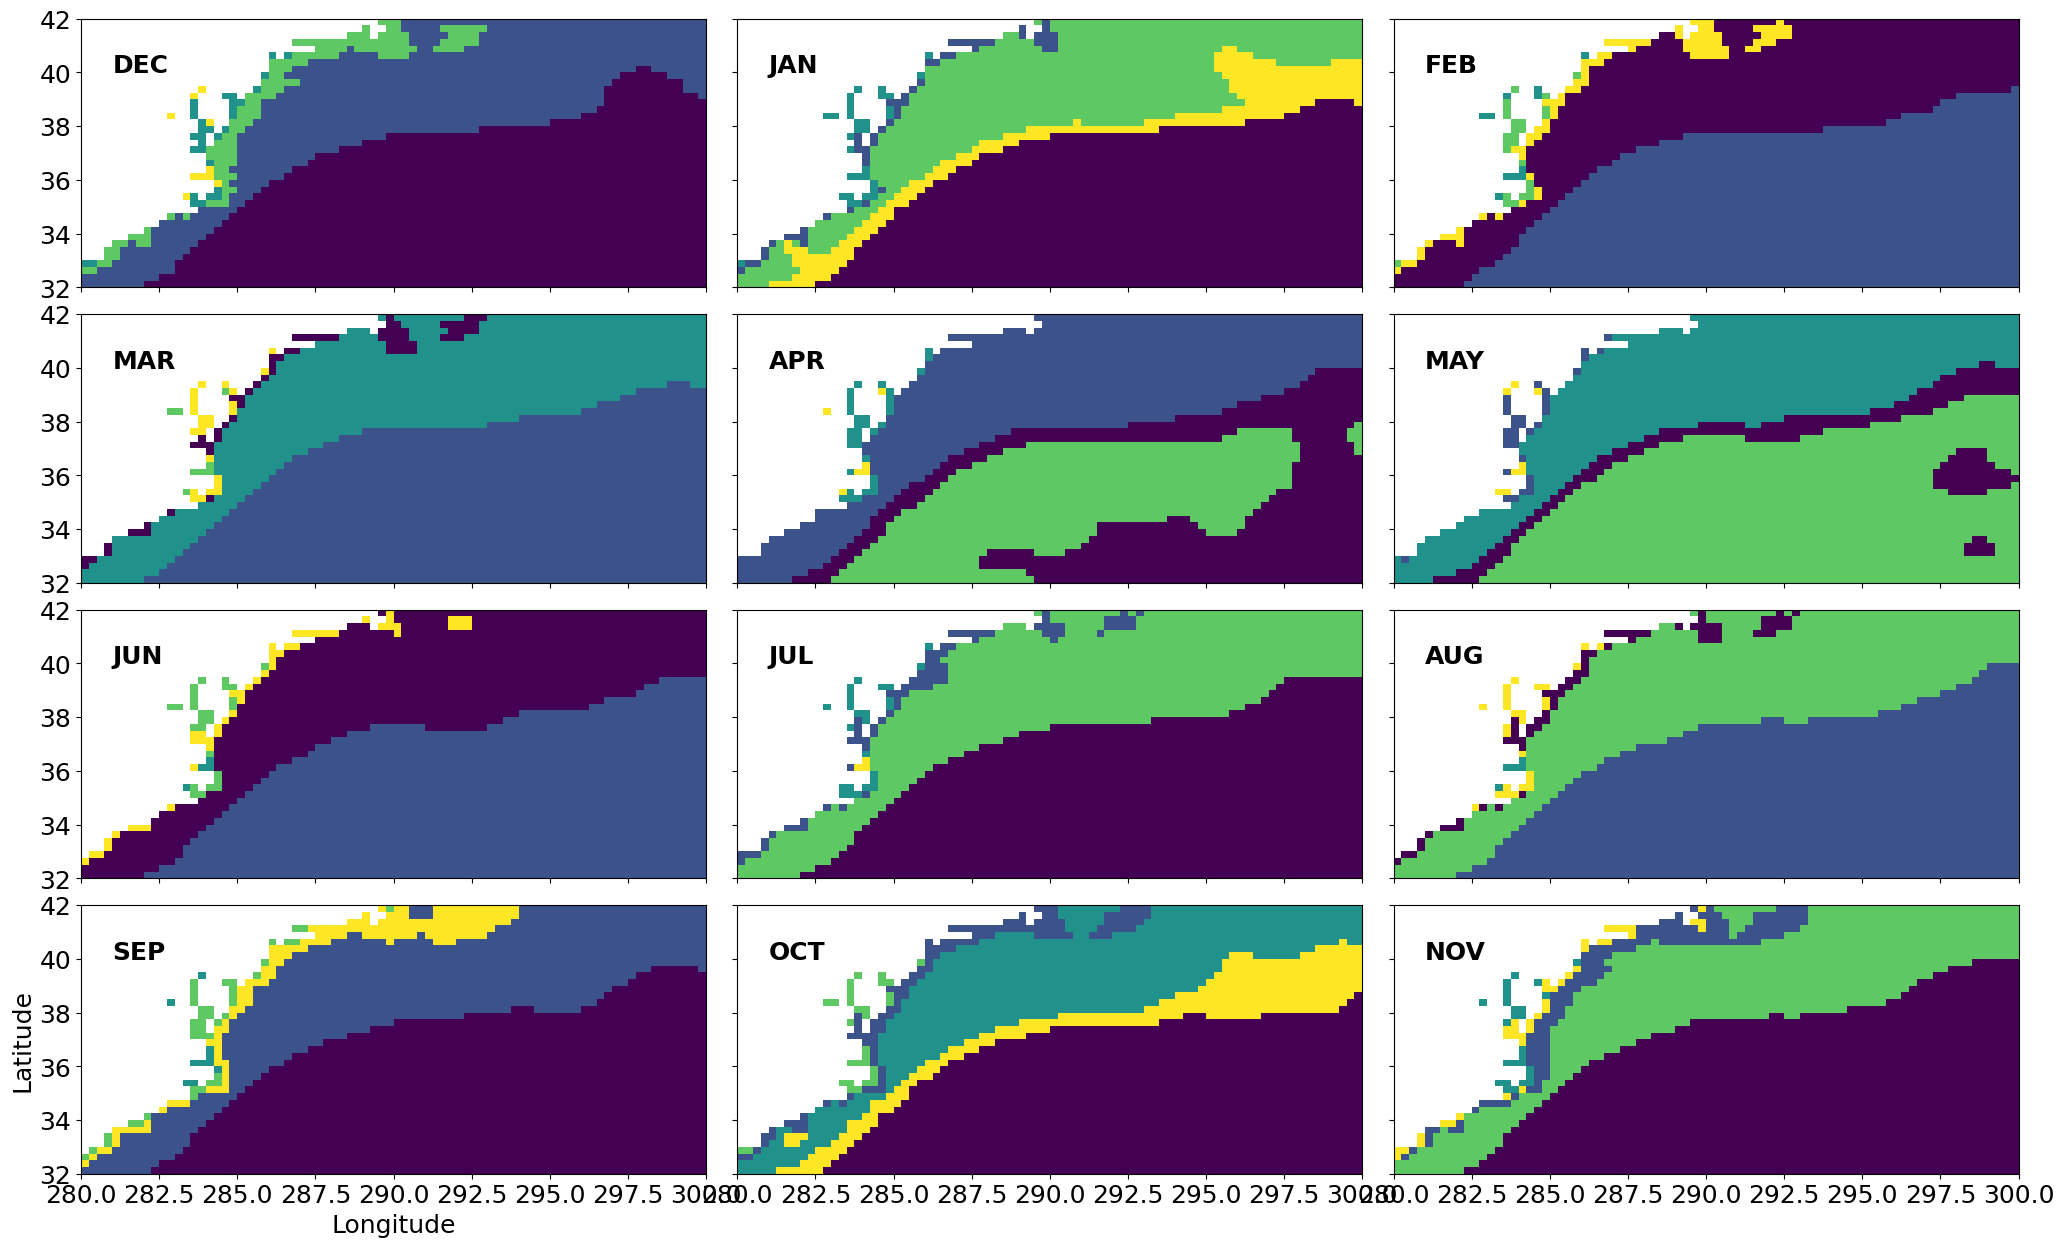

In [54]:
plot_clusters(cluster_clim_data(5))

In [55]:
# Save data array as mask
import pickle
with open('data/slope_sargasso_mask.pkl', 'wb') as outf:
    pickle.dump(cluster_clim_data, outf) 